In [49]:
from const import *
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [60]:
df = pd.read_csv("./data/games.csv")
df = df.loc[df.bugged==False].reset_index()

In [3]:
df.head(10)

,index,Unnamed: 0,hero0,ab00,ab01,ab02,ab03,hero1,ab10,ab11,...,ab92,ab93,radiant_win,has_abandon,match_seq_num,match_id,start_time,duration,lobby_type,bugged
0,0,0,45,6344,6482,9501,5511,35,8106,5154,...,5188,5156,True,False,5029500702,6004140884,1621599399,3137,0,False
1,2,2,7,7844,5123,5348,5023,91,5568,5485,...,5397,7902,True,False,5029500808,6004154453,1621599971,2562,0,False
2,3,3,96,5515,5516,5269,5013,60,5276,5353,...,5173,5270,True,False,5029500919,6004164017,1621600366,2177,0,False
3,4,4,60,5118,5043,5275,5102,39,5297,5298,...,5299,5447,True,False,5029500922,6004156368,1621600060,2401,0,False
4,5,5,111,5626,5043,5339,5638,3,5089,5090,...,5438,5087,True,False,5029500952,6004164782,1621600381,2153,0,False
5,6,6,53,5298,5299,7701,5022,31,5137,5459,...,6470,5598,True,False,5029500994,6004169155,1621600577,1976,0,False
6,7,7,126,7705,5460,5237,7325,129,5033,5099,...,5043,5042,False,False,5029501052,6004156945,1621600080,2443,0,False
7,8,8,15,5480,5132,5133,639,92,5482,5483,...,5140,5630,True,False,5029501071,6004161085,1621600241,2304,0,False
8,9,9,78,5651,5131,5565,5403,1,7841,5412,...,5518,7838,False,False,5029501145,6004134806,1621599134,3424,0,False
9,10,10,112,5651,5188,5652,5654,46,6344,5161,...,7325,5159,True,False,5029501160,6004180827,1621601048,1510,0,False


## Inspect data types

In [4]:
list(zip(df.columns, df.dtypes))

[('index', dtype('int64')),
 ('Unnamed: 0', dtype('int64')),
 ('hero0', dtype('int64')),
 ('ab00', dtype('int64')),
 ('ab01', dtype('int64')),
 ('ab02', dtype('int64')),
 ('ab03', dtype('int64')),
 ('hero1', dtype('int64')),
 ('ab10', dtype('int64')),
 ('ab11', dtype('int64')),
 ('ab12', dtype('int64')),
 ('ab13', dtype('int64')),
 ('hero2', dtype('int64')),
 ('ab20', dtype('int64')),
 ('ab21', dtype('int64')),
 ('ab22', dtype('int64')),
 ('ab23', dtype('int64')),
 ('hero3', dtype('int64')),
 ('ab30', dtype('int64')),
 ('ab31', dtype('int64')),
 ('ab32', dtype('int64')),
 ('ab33', dtype('int64')),
 ('hero4', dtype('int64')),
 ('ab40', dtype('int64')),
 ('ab41', dtype('int64')),
 ('ab42', dtype('int64')),
 ('ab43', dtype('int64')),
 ('hero5', dtype('int64')),
 ('ab50', dtype('int64')),
 ('ab51', dtype('int64')),
 ('ab52', dtype('int64')),
 ('ab53', dtype('int64')),
 ('hero6', dtype('int64')),
 ('ab60', dtype('int64')),
 ('ab61', dtype('int64')),
 ('ab62', dtype('int64')),
 ('ab63', dtyp

## Number of games and heros

In [5]:
ngames = len(df.index)
heros = df.hero0.unique()
nheros = len(heros)
ngames, nheros

(359580, 121)

## Radiant winning rate

In [6]:
sum(df.radiant_win) / ngames

0.5413176483675399

## Game time distribution

Text(0.5, 0, 'time(min)')

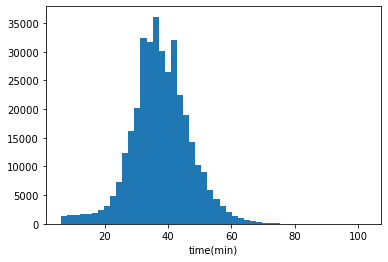

In [8]:
fg, ax = plt.subplots()
ax.hist(df.duration/60, bins=50)
ax.set_xlabel("time(min)")

## Heros' winning rate

In [32]:
df_hero = df[[f'hero{i}' for i in range(10)]]
if_win = df.radiant_win

hero_all = pd.concat([df_hero[f'hero{i}'].value_counts().sort_index() for i in range(10)], axis=1).sum(axis=1)
rad_win_hero = df_hero[if_win == True].iloc[:, :5]
rad_win_hero = pd.concat([rad_win_hero[f'hero{i}'].value_counts().sort_index() for i in range(5)], axis=1).sum(axis=1)
rad_fa_hero = df_hero[if_win == False].iloc[:, 5:]
rad_fa_hero = pd.concat([rad_fa_hero[f'hero{i}'].value_counts().sort_index() for i in range(5, 10)], axis=1).sum(axis=1)

hero_win_rate = pd.concat([hero_all, rad_win_hero, rad_fa_hero, rad_win_hero+rad_fa_hero], axis=1)
hero_win_rate.columns = ['total_occ', 'rad_win', 'rad_fa', 'win_count']
hero_win_rate['win_rate'] = hero_win_rate.win_count / hero_win_rate.total_occ
hero_win_rate

,total_occ,rad_win,rad_fa,win_count,win_rate
1,30182,7540,6320,13860,0.459214
2,30468,8676,7547,16223,0.532460
3,30357,8370,7391,15761,0.519188
4,30545,8500,7273,15773,0.516386
5,30616,7884,6649,14533,0.474686
...,...,...,...,...,...
123,30057,9234,8138,17372,0.577969
126,30458,7699,6495,14194,0.466019
128,30185,8578,7471,16049,0.531688
129,30445,8544,7293,15837,0.520184


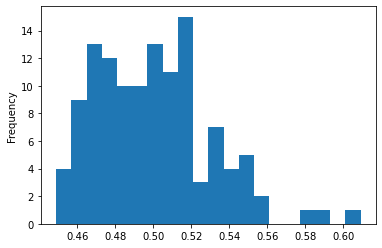

In [33]:
hero_win_rate.win_rate.plot.hist(bins=20)

In [43]:
# Heros with top 10 and bot 10 win rate
sorted_heros = hero_win_rate.sort_values(by=['win_rate'], ascending=False).index
print([id2hero[str(h)]['name'] for h in sorted_heros[:10]])
print([id2hero[str(h)]['name'] for h in sorted_heros[-10:]])

['npc_dota_hero_gyrocopter', 'npc_dota_hero_furion', 'npc_dota_hero_hoodwink', 'npc_dota_hero_terrorblade', 'npc_dota_hero_naga_siren', 'npc_dota_hero_sniper', 'npc_dota_hero_leshrac', 'npc_dota_hero_earth_spirit', 'npc_dota_hero_luna', 'npc_dota_hero_monkey_king']
['npc_dota_hero_skeleton_king', 'npc_dota_hero_broodmother', 'npc_dota_hero_pangolier', 'npc_dota_hero_huskar', 'npc_dota_hero_antimage', 'npc_dota_hero_spectre', 'npc_dota_hero_weaver', 'npc_dota_hero_ember_spirit', 'npc_dota_hero_slark', 'npc_dota_hero_necrolyte']


## Check ult abilities are correct

In [57]:
# every hero has at least one ult
ult_abs = {5606, 5121, 5125, 5640, 5129, 5133, 5137, 5141, 5654, 5144, 7705, 5149, 5153, 5157, 5161, 5165, 5176, 5177, 5181, 5185, 5189, 5193, 5197, 5725, 5221, 5225, 5229, 5240, 5244, 5248, 5252, 7304, 5258, 5262, 5266, 5267, 8340, 5274, 5278, 5279, 5288, 5292, 5300, 6343, 5323, 5331, 5337, 5342, 7906, 5348, 5356, 5360, 5364, 5369, 5380, 5394, 5398, 5403, 5415, 5425, 5429, 5437, 5447, 6482, 5461, 5465, 6491, 5470, 5474, 5483, 5488, 5497, 5507, 5512, 5517, 5006, 5521, 5010, 5013, 5527, 5018, 5022, 5026, 5030, 8106, 5035, 5551, 5043, 5047, 5049, 5568, 6598, 5064, 5067, 5584, 5073, 5588, 5077, 5081, 5594, 5085, 5598, 5089, 5602, 5093, 5097, 5612, 5101, 5616, 5105, 5109, 5622, 5113, 5117, 5630}

for i in range(100000):
    i1,i2,i3,i4 = df.ab00[i],df.ab01[i],df.ab02[i],df.ab03[i]
    if (i1 not in ult_abs) and (i2 not in ult_abs) and (i3 not in ult_abs) and (i4 not in ult_abs) and i1*i2*i3*i4!=0:
        print(df.match_id[i])
        print(f"{i1, id2ab[str(i1)]}")
        print(f"{i2, id2ab[str(i2)]}")
        print(f"{i3, id2ab[str(i3)]}")
        print(f"{i4, id2ab[str(i4)]}")

In [58]:
# every hero has no more than 2 ults
for i in range(100000):
    i1,i2,i3,i4 = df.ab00[i],df.ab01[i],df.ab02[i],df.ab03[i]
    if (i1 in ult_abs) + (i2 in ult_abs) + (i3 in ult_abs) + (i4 in ult_abs) > 1:
        print(df.match_id[i])
        print(f"{i1, id2ab[str(i1)]}")
        print(f"{i2, id2ab[str(i2)]}")
        print(f"{i3, id2ab[str(i3)]}")
        print(f"{i4, id2ab[str(i4)]}")